In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
df = pd.read_csv("Merged file.csv")
df

,Age,Occupation,Assets,Investments,Savings,Debt,Gross monthly income,Net monthly income,Rent/Mortgage,Utilities,...,Clothes,Phone,Subscriptions,Miscellaneous,Vacations,Gifts,Emergency Fund,Dining out,Movies,Other
0,30,Salaried,2550000,160000,42000,31000,51000,43000,6100,2100,...,1350,720,570,1150,2600,820,12200,2100,520,360
1,45,Homemaker,2650000,130000,62000,0,37000,33000,0,2350,...,1100,740,0,1080,1600,840,7200,1270,440,0
2,21,Student,90000,18000,8000,15000,13000,12000,3500,700,...,600,350,160,250,400,250,800,500,160,0
3,25,Salaried,2300000,130000,36000,54000,44000,37000,8500,1970,...,1260,690,540,1060,2060,760,10600,1860,440,340
4,29,Salaried,4400000,200000,51000,77000,66000,58000,12300,2550,...,2000,920,700,1500,5000,1500,20200,4100,720,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,36,Salaried,4150000,365000,73000,41500,86500,76500,9150,2775,...,2175,1030,930,1430,3575,1130,18300,3275,830,465
144,35,Self-Employed,8400000,530000,160000,0,98000,85000,0,3700,...,3200,1300,1150,1900,8300,2600,37000,7300,1260,830
145,25,Salaried,2300000,130000,36000,54000,44000,37000,8500,1970,...,1260,690,540,1060,2060,760,10600,1860,440,340
146,53,Retired,2250000,125000,56000,0,32500,29500,0,2250,...,970,560,0,990,1220,560,5300,890,230,0


In [3]:
# Strip column name spaces (very important)
df.columns = df.columns.str.strip()

# Show initial data
print(df.head())


   Age Occupation   Assets Investments Savings   Debt Gross monthly income  \
0   30   Salaried  2550000      160000   42000  31000                51000   
1   45  Homemaker  2650000      130000   62000      0                37000   
2   21    Student    90000       18000    8000  15000                13000   
3   25   Salaried  2300000      130000   36000  54000                44000   
4   29   Salaried  4400000      200000   51000  77000                66000   

  Net monthly income Rent/Mortgage Utilities  ... Clothes Phone Subscriptions  \
0              43000          6100      2100  ...    1350   720           570   
1              33000             0      2350  ...    1100   740             0   
2              12000          3500       700  ...     600   350           160   
3              37000          8500      1970  ...    1260   690           540   
4              58000         12300      2550  ...    2000   920           700   

  Miscellaneous Vacations Gifts Emergency Fu

**column names**

In [4]:
print("📋 Column Names:")
print(df.columns.tolist())


📋 Column Names:
['Age', 'Occupation', 'Assets', 'Investments', 'Savings', 'Debt', 'Gross monthly income', 'Net monthly income', 'Rent/Mortgage', 'Utilities', 'Insurance', 'Car Payment', 'Debt Payments', 'Groceries', 'Clothes', 'Phone', 'Subscriptions', 'Miscellaneous', 'Vacations', 'Gifts', 'Emergency Fund', 'Dining out', 'Movies', 'Other']


**Convert Financial Columns to Numeric**

In [5]:
# Columns to convert (check they exist first)
columns_to_convert = [
    "Assets", "Investments", "Savings", "Debt",
    "Gross monthly income", "Net monthly income", "Emergency Fund"
]

for col in columns_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '').str.strip(),
            errors='coerce'
        )


**datatypes of all columns**

In [11]:
print(" Data Types:")
print(df.dtypes)


 Data Types:
Age                       int64
Occupation               object
Assets                    int64
Investments               int64
Savings                   int64
Debt                      int64
Gross monthly income      int64
Net monthly income        int64
Rent/Mortgage             int64
Utilities                 int64
Insurance                 int64
Car Payment               int64
Debt Payments             int64
Groceries                 int64
Clothes                   int64
Phone                     int64
Subscriptions             int64
Miscellaneous             int64
Vacations                 int64
Gifts                     int64
Emergency Fund            int64
Dining out                int64
Movies                    int64
Other                     int64
Total Expenses            int64
Annual Income             int64
Savings Rate (%)        float64
Debt to Asset Ratio     float64
dtype: object


**Total Expenses**

In [7]:
# Calculate Total Expenses
# Define expense columns (only if they exist in your data)
expense_cols = [
    "Rent/Mortgage", "Utilities", "Insurance", "Car Payment",
    "Debt Payments", "Groceries", "Clothes", "Phone",
    "Subscriptions", "Miscellaneous", "Vacations", "Gifts",
    "Dining out", "Movies", "Other"
]

# Filter for valid ones only
valid_expenses = [col for col in expense_cols if col in df.columns]

# Convert and sum
for col in valid_expenses:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

df["Total Expenses"] = df[valid_expenses].sum(axis=1)

# Preview result
print(df[["Total Expenses"]].head())


   Total Expenses
0           28160
1           17320
2           10170
3           28500
4           45360


**Calculate Annual Income, Savings Rate, Debt-to-Asset Ratio**

In [8]:
df["Annual Income"] = df["Gross monthly income"] * 12

df["Savings Rate (%)"] = (df["Savings"] / df["Annual Income"] * 100).round(2)
df["Debt to Asset Ratio"] = (df["Debt"] / df["Assets"]).round(2)

# View a sample
print(df[["Gross monthly income", "Savings", "Savings Rate (%)", "Debt to Asset Ratio"]].head())


   Gross monthly income  Savings  Savings Rate (%)  Debt to Asset Ratio
0                 51000    42000              6.86                 0.01
1                 37000    62000             13.96                 0.00
2                 13000     8000              5.13                 0.17
3                 44000    36000              6.82                 0.02
4                 66000    51000              6.44                 0.02


**Top saving rates**

In [88]:
top_savers = df[["Age", "Occupation", "Gross monthly income", "Savings", "Savings Rate (%)"]]
print(top_savers.sort_values(by="Savings Rate (%)", ascending=False).head())


    Age         Occupation  Gross monthly income  Savings  Savings Rate (%)
73   42           Salaried                 83500  2000000            199.60
81   65            Retired                 58000  1200000            172.41
72   58            Retired                 83000  1500000            150.60
70   50  Retired Professor                 70000   700000             83.33
80   29           Salaried                 55000   450000             68.18


**Summary statistics**

In [12]:
print("==== Summary Statistics ====")
print(df.describe(include='all'))

==== Summary Statistics ====
               Age Occupation        Assets   Investments       Savings  \
count   148.000000        148  1.480000e+02  1.480000e+02  1.480000e+02   
unique         NaN         26           NaN           NaN           NaN   
top            NaN   Salaried           NaN           NaN           NaN   
freq           NaN         49           NaN           NaN           NaN   
mean     40.581081        NaN  4.482337e+06  3.667513e+05  1.571663e+05   
std      10.249947        NaN  3.628001e+06  4.346171e+05  2.613040e+05   
min      21.000000        NaN  9.000000e+04  0.000000e+00  0.000000e+00   
25%      32.000000        NaN  2.280398e+06  1.300000e+05  5.400000e+04   
50%      41.000000        NaN  3.600000e+06  2.500000e+05  7.550000e+04   
75%      49.000000        NaN  6.025000e+06  4.025808e+05  1.512500e+05   
max      65.000000        NaN  3.000000e+07  3.500000e+06  2.000000e+06   

                Debt  Gross monthly income  Net monthly income  Rent/M

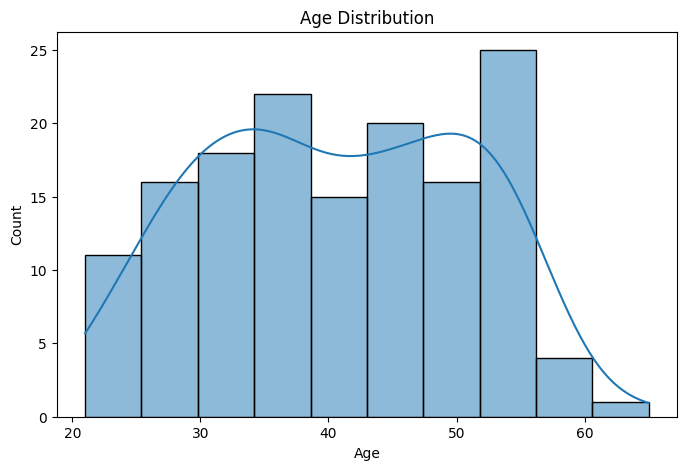

In [13]:
if "Age" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["Age"].dropna(), bins=10, kde=True)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()


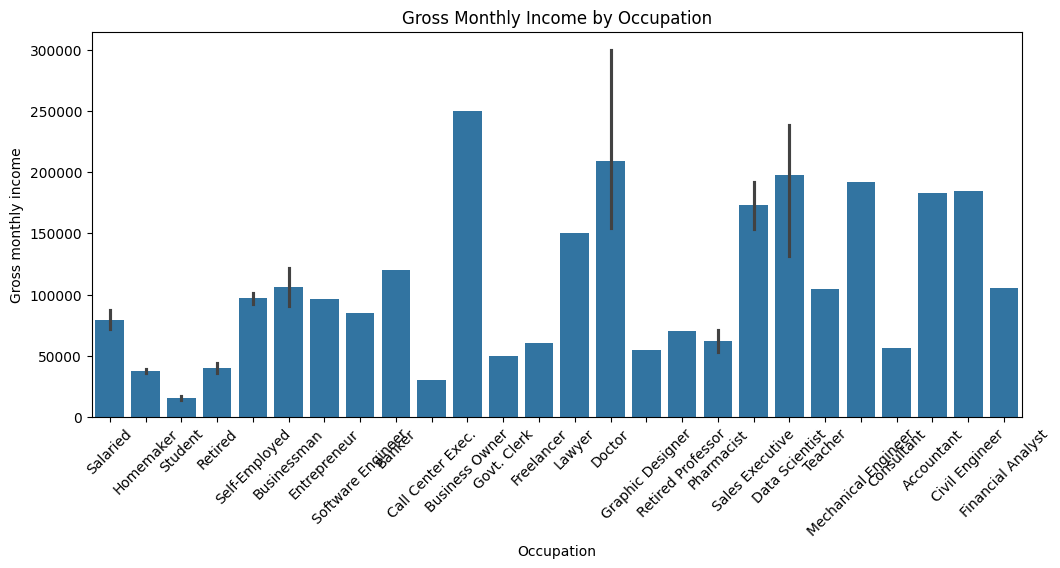

In [14]:
if "Occupation" in df.columns:
    plt.figure(figsize=(12, 5))
    sns.barplot(x="Occupation", y="Gross monthly income", data=df)
    plt.title("Gross Monthly Income by Occupation")
    plt.xticks(rotation=45)
    plt.show()


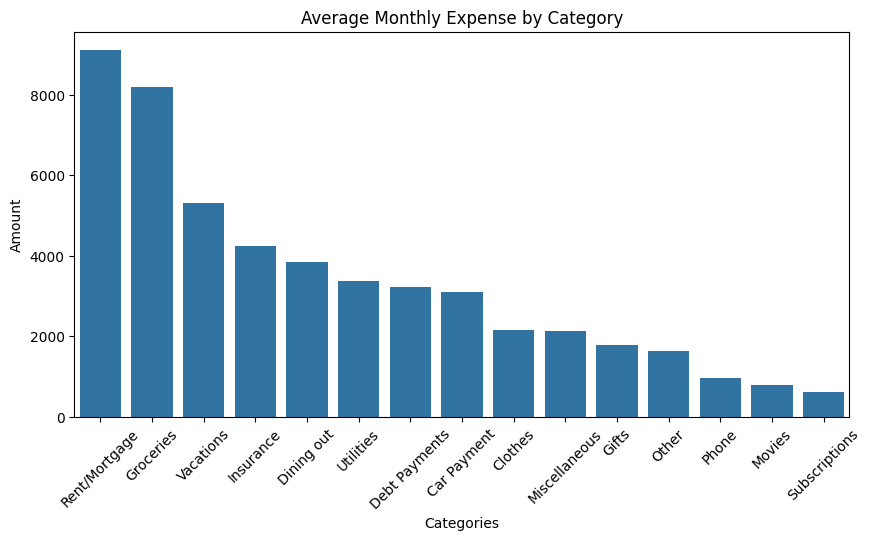

In [15]:
avg_exp = df[valid_expenses].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_exp.index, y=avg_exp.values)
plt.title("Average Monthly Expense by Category")
plt.ylabel("Amount")
plt.xlabel("Categories")
plt.xticks(rotation=45)
plt.show()


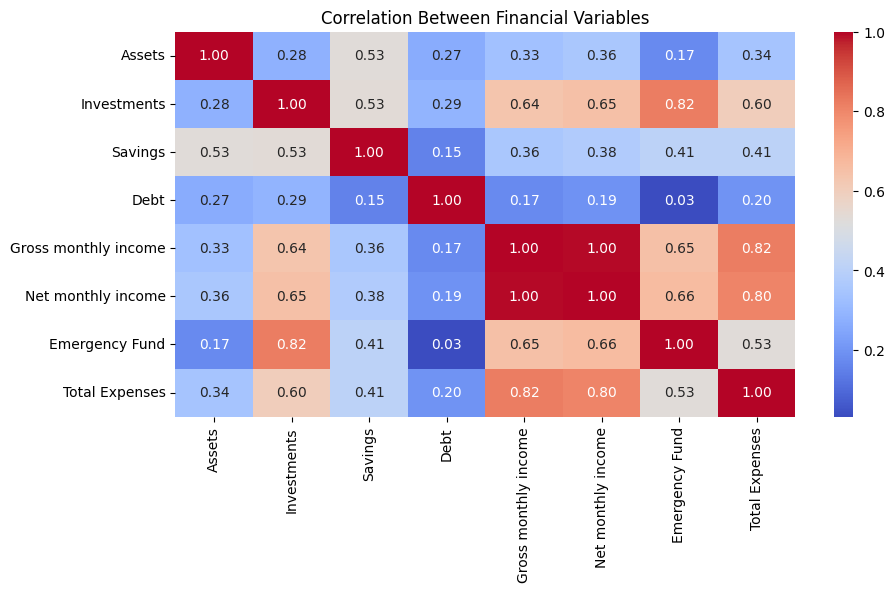

In [16]:
plt.figure(figsize=(10, 5))
heatmap_cols = columns_to_convert + ["Total Expenses"]
sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Financial Variables")
plt.show()


**Expense Prediction Model**

In [17]:
X = df[[
    "Gross monthly income", "Net monthly income", "Savings",    #Define Features and Target
    "Investments", "Debt", "Emergency Fund"
]]

y = df["Total Expenses"]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Train-Test Split


In [19]:
model = LinearRegression()  # Train a Regression Model
model.fit(X_train, y_train)


LinearRegression()

In [20]:
y_pred = model.predict(X_test)  # Evaluate Model

print("R² Score:", r2_score(y_test, y_pred)) #model explains 83% of the variance in total expenses.
                                             #Indicates that features (income, savings, debt, etc.) are highly predictive of expenses.
print("MSE:", mean_squared_error(y_test, y_pred)) #average of the squared errors between predicted and actual values.

R² Score: 0.8275977041685347
MSE: 204902663.39772674


In [21]:
rmse = np.sqrt(204902663.39772674)  #average size of the error between actual and predicted monthly expenses
                               #Some predictions might be off by more, some by less, but ₹14.3K is the typical error margin. Now goal is to reduce it


print("RMSE:", rmse)

RMSE: 14314.421518095893


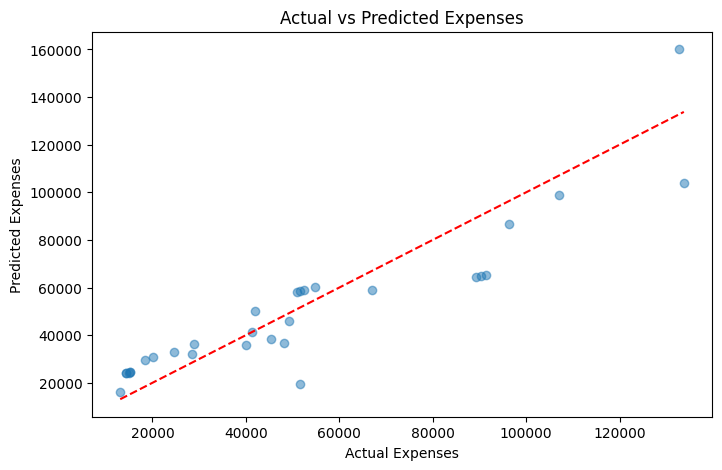

In [22]:
import matplotlib.pyplot as plt   #  Check Residuals

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Actual vs Predicted Expenses")
plt.show()


**Random forest**

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [24]:
rf_preds = rf_model.predict(X_test)


In [25]:

# Evaluation
r2 = r2_score(y_test, rf_preds)
mse = mean_squared_error(y_test, rf_preds)
rmse = np.sqrt(mse)

print("Random Forest R²:", r2) #model now explains 93% of the variation in total expenses
print("Random Forest MSE:", mse)
print("Random Forest RMSE:", rmse) #predictions are off by ₹9,299, down from ₹14.3K


Random Forest R²: 0.9272471277609263
Random Forest MSE: 86467858.32941332
Random Forest RMSE: 9298.809511405927


In [26]:
print("Linear R²:", r2_score(y_test, y_pred))
print("Random Forest R²:", r2_score(y_test, rf_preds))  

Linear R²: 0.8275977041685347
Random Forest R²: 0.9272471277609263


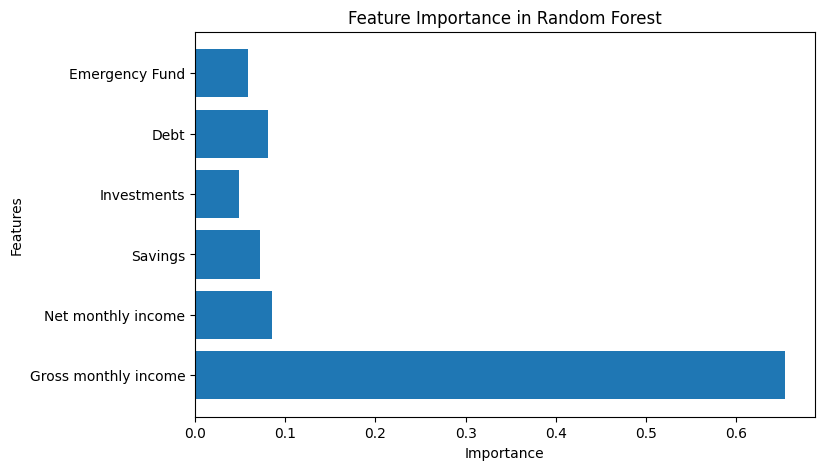

In [27]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, importances)
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


**Model**

In [28]:
import joblib
joblib.dump(rf_model, "expense_predictor_rf.pkl")


['expense_predictor_rf.pkl']

**the prediction + advice function**

In [32]:
import pandas as pd
import joblib

# Load the trained expense prediction model
expense_model = joblib.load("expense_predictor_rf.pkl")

def analyze_expense_profile(user_data: dict):
    df = pd.DataFrame([user_data])

    # Define the features to use for prediction
    input_features = [
        "Gross monthly income", "Net monthly income", "Savings",
        "Investments", "Debt", "Emergency Fund"
    ]
    X = df[input_features]

    # Predict expense using model
    predicted_expense = expense_model.predict(X)[0]
    income = user_data["Gross monthly income"]

    # 🧠 New logic to cap and warn if overspending
    if predicted_expense > income:
        logical_expense = income  # Cap to max income
        overspending = True
    else:
        logical_expense = predicted_expense
        overspending = False

    # Fixed vs variable classification
    fixed_expense = 0.6 * logical_expense
    variable_expense = 0.4 * logical_expense

    # Future liability estimation
    future_emi = user_data.get("Debt", 0) / 12
    future_medical = 1000 if user_data["Age"] > 50 else 0
    future_tuition = 2000 if user_data["Age"] < 25 else 0
    total_future_liabilities = future_emi + future_medical + future_tuition

    # Spending risk classification
    spending_ratio = logical_expense / income if income > 0 else 0
    if spending_ratio > 0.8:
        spending_flag = "⚠️ Overexposed — spending more than 80% of income"
    elif spending_ratio < 0.3:
        spending_flag = "✅ Very conservative spending"
    else:
        spending_flag = "🟡 Moderate spending level"

    # Prepare advice output
    advice = [
        f"📊 Predicted Monthly Expense: ₹{round(predicted_expense):,}",
        f"🔷 Fixed Portion: ₹{round(fixed_expense):,}, 🔶 Variable Portion: ₹{round(variable_expense):,}",
        f"💸 Expected Future Liabilities: ₹{round(total_future_liabilities):,} (EMI + Medical + Tuition)",
        f"📉 Spending to Income Ratio: {spending_ratio:.2f}",
        f"📝 Spending Risk Flag: {spending_flag}"
    ]

    # ⚠️ Additional overspending warning
    if overspending:
        advice.append("🚨 Your predicted expenses exceed your income!")
        advice.append(f"💡 We've capped expenses to ₹{round(logical_expense):,} for realistic analysis.")
        advice.append("📉 Consider reducing variable expenses or increasing income.")

    # Return results
    return {
        "Predicted Expense": round(predicted_expense),
        "Adjusted Expense": round(logical_expense),
        "Fixed": round(fixed_expense),
        "Variable": round(variable_expense),
        "Liabilities": round(total_future_liabilities),
        "Spending Ratio": round(spending_ratio, 2),
        "Flag": spending_flag,
        "Advice": advice
    }


**Testing example**

In [33]:
user_data = {
    "Gross monthly income": 70000,
    "Net monthly income": 60000,
    "Savings": 150000,
    "Investments": 100000,
    "Debt": 240000,
    "Emergency Fund": 30000,
    "Age": 24
}

result = analyze_expense_profile(user_data)

for line in result["Advice"]:
    print(line)


📊 Predicted Monthly Expense: ₹70,774
🔷 Fixed Portion: ₹42,000, 🔶 Variable Portion: ₹28,000
💸 Expected Future Liabilities: ₹22,000 (EMI + Medical + Tuition)
📉 Spending to Income Ratio: 1.00
📝 Spending Risk Flag: ⚠️ Overexposed — spending more than 80% of income
🚨 Your predicted expenses exceed your income!
💡 We've capped expenses to ₹70,000 for realistic analysis.
📉 Consider reducing variable expenses or increasing income.


In [34]:
test_user_2 = {
    "Gross monthly income": 90000,
    "Net monthly income": 80000,
    "Savings": 200000,
    "Investments": 150000,
    "Debt": 120000,
    "Emergency Fund": 50000,
    "Age": 32
}

result = analyze_expense_profile(test_user_2)

for line in result["Advice"]:
    print(line)


📊 Predicted Monthly Expense: ₹66,611
🔷 Fixed Portion: ₹39,967, 🔶 Variable Portion: ₹26,644
💸 Expected Future Liabilities: ₹10,000 (EMI + Medical + Tuition)
📉 Spending to Income Ratio: 0.74
📝 Spending Risk Flag: 🟡 Moderate spending level
